In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
 data_path = "../data/processed/user_events_clean.csv"

df = pd.read_csv(data_path)

df["event_timestamp"] = pd.to_datetime(
    df["event_timestamp"]
)

print("Data loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Data loaded successfully!
Rows: 357639
Columns: 24


In [3]:
df.head()

,event_id,user_id,session_id,event_timestamp,event_type,device,location,traffic_source,customer_type,product_category,...,month,month_name,week,day_of_week,hour,is_weekend,event_date,event_order,duration_minutes,user_purchased
0,E00000001,U000001,S0000001,2025-05-24 06:13:00,visit,Mobile,Pune,Google,Returning,NaN,...,5,May,21,Saturday,6,1,2025-05-24,1,0.0,0
1,E00000002,U000002,S0000002,2025-01-19 02:55:00,visit,Tablet,Ahmedabad,Email,New,NaN,...,1,January,3,Sunday,2,1,2025-01-19,1,7.0,0
2,E00000003,U000002,S0000002,2025-01-19 03:02:00,product_view,Tablet,Ahmedabad,Email,New,Sports,...,1,January,3,Sunday,3,1,2025-01-19,2,7.0,0
3,E00000004,U000003,S0000003,2025-02-16 08:32:00,visit,Desktop,Chennai,Direct,New,NaN,...,2,February,7,Sunday,8,1,2025-02-16,1,7.0,0
4,E00000005,U000003,S0000003,2025-02-16 08:34:00,product_view,Desktop,Chennai,Direct,New,Electronics,...,2,February,7,Sunday,8,1,2025-02-16,2,7.0,0


In [4]:
df.columns.tolist()

['event_id',
 'user_id',
 'session_id',
 'event_timestamp',
 'event_type',
 'device',
 'location',
 'traffic_source',
 'customer_type',
 'product_category',
 'product',
 'amount',
 'date',
 'year',
 'month',
 'month_name',
 'week',
 'day_of_week',
 'hour',
 'is_weekend',
 'event_date',
 'event_order',
 'duration_minutes',
 'user_purchased']

In [5]:
funnel_events = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

session_funnel = (
    df.groupby(
        "session_id"
    )["event_type"]
    .apply(
        lambda x: set(x)
    )
    .reset_index()
)

In [6]:
session_funnel.head()

,session_id,event_type
0,S0000001,{visit}
1,S0000002,"{product_view, visit}"
2,S0000003,"{product_view, add_to_cart, visit}"
3,S0000004,"{product_view, visit}"
4,S0000005,"{product_view, visit}"


In [7]:
for stage in funnel_events:

    session_funnel[stage] = (
        session_funnel["event_type"]
        .apply(
            lambda x: int(stage in x)
        )
    )

In [8]:
session_funnel.head()

,session_id,event_type,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,{visit},1,0,0,0,0,0
1,S0000002,"{product_view, visit}",1,1,0,0,0,0
2,S0000003,"{product_view, add_to_cart, visit}",1,1,1,0,0,0
3,S0000004,"{product_view, visit}",1,1,0,0,0,0
4,S0000005,"{product_view, visit}",1,1,0,0,0,0


In [9]:
session_funnel = session_funnel.drop(
    columns=["event_type"]
)

In [12]:
session_funnel.head()                  

,session_id,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,1,0,0,0,0,0
1,S0000002,1,1,0,0,0,0
2,S0000003,1,1,1,0,0,0
3,S0000004,1,1,0,0,0,0
4,S0000005,1,1,0,0,0,0


In [11]:
session_info = (
    df.sort_values("event_timestamp")
    .groupby("session_id")
    .first()
    .reset_index()
)

In [13]:
session_info = session_info[
    [
        "session_id",
        "user_id",
        "device",
        "location",
        "traffic_source",
        "customer_type",
        "event_timestamp"
    ]
]

In [14]:
session_info = session_info.rename(
    columns={
        "event_timestamp": "session_start"
    }
)

In [15]:
session_info.head()

,session_id,user_id,device,location,traffic_source,customer_type,session_start
0,S0000001,U000001,Mobile,Pune,Google,Returning,2025-05-24 06:13:00
1,S0000002,U000002,Tablet,Ahmedabad,Email,New,2025-01-19 02:55:00
2,S0000003,U000003,Desktop,Chennai,Direct,New,2025-02-16 08:32:00
3,S0000004,U000004,Mobile,Kolkata,Direct,New,2025-02-18 13:20:00
4,S0000005,U000004,Mobile,Kolkata,Direct,New,2025-03-30 00:28:00


In [16]:
session_funnel = session_funnel.merge(
    session_info,
    on="session_id",
    how="left"
)

In [17]:
session_funnel.head()

,session_id,visit,product_view,add_to_cart,signup,checkout,purchase,user_id,device,location,traffic_source,customer_type,session_start
0,S0000001,1,0,0,0,0,0,U000001,Mobile,Pune,Google,Returning,2025-05-24 06:13:00
1,S0000002,1,1,0,0,0,0,U000002,Tablet,Ahmedabad,Email,New,2025-01-19 02:55:00
2,S0000003,1,1,1,0,0,0,U000003,Desktop,Chennai,Direct,New,2025-02-16 08:32:00
3,S0000004,1,1,0,0,0,0,U000004,Mobile,Kolkata,Direct,New,2025-02-18 13:20:00
4,S0000005,1,1,0,0,0,0,U000004,Mobile,Kolkata,Direct,New,2025-03-30 00:28:00


In [18]:
print(
    "Rows:",
    len(session_funnel)
)

print(
    "Columns:",
    len(session_funnel.columns)
)

Rows: 169834
Columns: 13


In [19]:
session_funnel["visit"].value_counts()

visit
1    169834
Name: count, dtype: int64

In [20]:
funnel_counts = {
    "Visit": session_funnel["visit"].sum(),

    "Product View": session_funnel["product_view"].sum(),

    "Add to Cart": session_funnel["add_to_cart"].sum(),

    "Signup": session_funnel["signup"].sum(),

    "Checkout": session_funnel["checkout"].sum(),

    "Purchase": session_funnel["purchase"].sum()
}

funnel_counts

{'Visit': np.int64(169834),
 'Product View': np.int64(96055),
 'Add to Cart': np.int64(38646),
 'Signup': np.int64(24712),
 'Checkout': np.int64(17541),
 'Purchase': np.int64(10851)}

In [21]:
funnel_df = pd.DataFrame(
    {
        "stage": list(funnel_counts.keys()),
        "users": list(funnel_counts.values())
    }
)

funnel_df

,stage,users
0,Visit,169834
1,Product View,96055
2,Add to Cart,38646
3,Signup,24712
4,Checkout,17541
5,Purchase,10851


In [22]:
funnel_df["previous_users"] = (
    funnel_df["users"].shift(1)
)

In [23]:
funnel_df["stage_conversion_rate"] = (
    funnel_df["users"]
    / funnel_df["previous_users"]
    * 100
)

In [24]:
funnel_df.loc[
    funnel_df["stage"] == "Visit",
    "stage_conversion_rate"
] = 100

In [25]:
funnel_df["drop_off_users"] = (
    funnel_df["previous_users"]
    - funnel_df["users"]
)

In [26]:
funnel_df["drop_off_rate"] = (
    funnel_df["drop_off_users"]
    / funnel_df["previous_users"]
    * 100
)

In [27]:
funnel_df.loc[
    funnel_df["stage"] == "Visit",
    "drop_off_rate"
] = 0

In [28]:
funnel_df

,stage,users,previous_users,stage_conversion_rate,drop_off_users,drop_off_rate
0,Visit,169834,NaN,100.000000,NaN,0.000000
1,Product View,96055,169834.0,56.558169,73779.0,43.441831
2,Add to Cart,38646,96055.0,40.233200,57409.0,59.766800
3,Signup,24712,38646.0,63.944522,13934.0,36.055478
4,Checkout,17541,24712.0,70.981709,7171.0,29.018291
5,Purchase,10851,17541.0,61.860783,6690.0,38.139217


In [29]:
total_visitors = funnel_df.loc[
    funnel_df["stage"] == "Visit",
    "users"
].iloc[0]

total_purchasers = funnel_df.loc[
    funnel_df["stage"] == "Purchase",
    "users"
].iloc[0]

overall_conversion = (
    total_purchasers
    / total_visitors
    * 100
)

print(
    f"Overall Conversion Rate: {overall_conversion:.2f}%"
)

Overall Conversion Rate: 6.39%


In [30]:
leakage_df = funnel_df[
    funnel_df["stage"] != "Visit"
]

biggest_leakage = leakage_df.loc[
    leakage_df["drop_off_rate"].idxmax()
]

print(
    "Biggest Leakage Stage:",
    biggest_leakage["stage"]
)

print(
    f"Drop-off Rate: "
    f"{biggest_leakage['drop_off_rate']:.2f}%"
)

Biggest Leakage Stage: Add to Cart
Drop-off Rate: 59.77%


In [31]:
funnel_df["overall_conversion_rate"] = (
    funnel_df["users"]
    / total_visitors
    * 100
)

In [32]:
funnel_df

,stage,users,previous_users,stage_conversion_rate,drop_off_users,drop_off_rate,overall_conversion_rate
0,Visit,169834,NaN,100.000000,NaN,0.000000,100.000000
1,Product View,96055,169834.0,56.558169,73779.0,43.441831,56.558169
2,Add to Cart,38646,96055.0,40.233200,57409.0,59.766800,22.755161
3,Signup,24712,38646.0,63.944522,13934.0,36.055478,14.550679
4,Checkout,17541,24712.0,70.981709,7171.0,29.018291,10.328321
5,Purchase,10851,17541.0,61.860783,6690.0,38.139217,6.389180


In [33]:
funnel_df[
    [
        "stage",
        "users",
        "stage_conversion_rate",
        "drop_off_rate",
        "overall_conversion_rate"
    ]
]

,stage,users,stage_conversion_rate,drop_off_rate,overall_conversion_rate
0,Visit,169834,100.000000,0.000000,100.000000
1,Product View,96055,56.558169,43.441831,56.558169
2,Add to Cart,38646,40.233200,59.766800,22.755161
3,Signup,24712,63.944522,36.055478,14.550679
4,Checkout,17541,70.981709,29.018291,10.328321
5,Purchase,10851,61.860783,38.139217,6.389180


In [34]:
biggest_leakage = funnel_df.loc[
    funnel_df["drop_off_rate"].idxmax()
]

print("BIGGEST LEAKAGE POINT")
print("----------------------")
print("Stage:", biggest_leakage["stage"])
print(
    f"Drop-off Rate: "
    f"{biggest_leakage['drop_off_rate']:.2f}%"
)
print(
    f"Users Lost: "
    f"{biggest_leakage['drop_off_users']:,.0f}"
)

BIGGEST LEAKAGE POINT
----------------------
Stage: Add to Cart
Drop-off Rate: 59.77%
Users Lost: 57,409


In [35]:
current_cart_rate = (
    funnel_df.loc[
        funnel_df["stage"] == "Add to Cart",
        "stage_conversion_rate"
    ].iloc[0]
)

product_view_users = (
    funnel_df.loc[
        funnel_df["stage"] == "Product View",
        "users"
    ].iloc[0]
)

improved_cart_rate = current_cart_rate + 10

additional_cart_users = (
    product_view_users
    * (improved_cart_rate - current_cart_rate)
    / 100
)

print(
    f"Current Product View → Cart Rate: "
    f"{current_cart_rate:.2f}%"
)

print(
    f"Improved Rate: "
    f"{improved_cart_rate:.2f}%"
)

print(
    f"Potential Additional Cart Users: "
    f"{additional_cart_users:,.0f}"
)

Current Product View → Cart Rate: 40.23%
Improved Rate: 50.23%
Potential Additional Cart Users: 9,606


In [36]:
funnel_df.to_csv(
    "../data/processed/funnel_summary.csv",
    index=False
)

print("Funnel summary saved successfully!")

Funnel summary saved successfully!


In [37]:
device_funnel = (
    df.groupby(
        ["session_id", "device"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

device_funnel.head()

,session_id,device,event_type
0,S0000001,Mobile,{visit}
1,S0000002,Tablet,"{product_view, visit}"
2,S0000003,Desktop,"{product_view, add_to_cart, visit}"
3,S0000004,Mobile,"{product_view, visit}"
4,S0000005,Mobile,"{product_view, visit}"


In [38]:
for stage in funnel_events:

    device_funnel[stage] = (
        device_funnel["event_type"]
        .apply(
            lambda x: int(stage in x)
        )
    )

In [39]:
device_funnel = device_funnel.drop(
    columns=["event_type"]
)

In [40]:
device_funnel.head()

,session_id,device,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,Mobile,1,0,0,0,0,0
1,S0000002,Tablet,1,1,0,0,0,0
2,S0000003,Desktop,1,1,1,0,0,0
3,S0000004,Mobile,1,1,0,0,0,0
4,S0000005,Mobile,1,1,0,0,0,0


In [41]:
devices = [
    "Mobile",
    "Desktop",
    "Tablet"
]

In [42]:
device_funnel_summary = []

for device in devices:

    temp = device_funnel[
        device_funnel["device"] == device
    ]

    device_funnel_summary.append({
        "device": device,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

device_funnel_summary = pd.DataFrame(
    device_funnel_summary
)

device_funnel_summary

,device,visit,product_view,add_to_cart,signup,checkout,purchase
0,Mobile,101754,53721,20030,11745,7613,4257
1,Desktop,59820,38267,17236,12229,9483,6359
2,Tablet,8260,4067,1380,738,445,235


In [43]:
device_funnel_summary["conversion_rate"] = (
    device_funnel_summary["purchase"]
    / device_funnel_summary["visit"]
    * 100
)

In [44]:
device_funnel_summary

,device,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Mobile,101754,53721,20030,11745,7613,4257,4.183619
1,Desktop,59820,38267,17236,12229,9483,6359,10.630224
2,Tablet,8260,4067,1380,738,445,235,2.845036


In [45]:
device_funnel_summary = (
    device_funnel_summary
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

device_funnel_summary

,device,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Desktop,59820,38267,17236,12229,9483,6359,10.630224
1,Mobile,101754,53721,20030,11745,7613,4257,4.183619
2,Tablet,8260,4067,1380,738,445,235,2.845036


In [46]:
device_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for device in devices:

    row = device_funnel_summary[
        device_funnel_summary["device"] == device
    ].iloc[0]

    result = {
        "device": device
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        previous_users = row[previous_stage]
        current_users = row[current_stage]

        conversion = (
            current_users
            / previous_users
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    device_stage_results.append(result)

device_stage_results = pd.DataFrame(
    device_stage_results
)

device_stage_results

,device,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Mobile,52.794976,37.285233,58.637044,64.819072,55.917510
1,Desktop,63.970244,45.041419,70.950337,77.545179,67.056839
2,Tablet,49.237288,33.931645,53.478261,60.298103,52.808989


In [47]:
for device in devices:

    row = device_stage_results[
        device_stage_results["device"] == device
    ].iloc[0]

    stage_columns = [
        col for col in device_stage_results.columns
        if col != "device"
    ]

    weakest_stage = row[
        stage_columns
    ].idxmin()

    weakest_rate = row[
        weakest_stage
    ]

    print(
        f"{device}: "
        f"{weakest_stage} = "
        f"{weakest_rate:.2f}%"
    )

Mobile: product_view_to_add_to_cart = 37.29%
Desktop: product_view_to_add_to_cart = 45.04%
Tablet: product_view_to_add_to_cart = 33.93%


In [48]:
mobile_conversion = device_funnel_summary.loc[
    device_funnel_summary["device"] == "Mobile",
    "conversion_rate"
].iloc[0]

desktop_conversion = device_funnel_summary.loc[
    device_funnel_summary["device"] == "Desktop",
    "conversion_rate"
].iloc[0]

difference = (
    desktop_conversion
    - mobile_conversion
)

print(
    f"Mobile Conversion: {mobile_conversion:.2f}%"
)

print(
    f"Desktop Conversion: {desktop_conversion:.2f}%"
)

print(
    f"Desktop - Mobile Difference: {difference:.2f} percentage points"
)

Mobile Conversion: 4.18%
Desktop Conversion: 10.63%
Desktop - Mobile Difference: 6.45 percentage points


In [49]:
device_revenue = (
    df[df["event_type"] == "purchase"]
    .groupby("device")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

In [50]:
device_revenue["average_order_value"] = (
    device_revenue["revenue"]
    / device_revenue["orders"]
)

In [51]:
device_revenue

,device,orders,revenue,purchasers,average_order_value
0,Desktop,6359,1.086675e+08,5501,17088.765388
1,Mobile,4257,7.345866e+07,4018,17255.968548
2,Tablet,235,3.475479e+06,223,14789.273489


In [52]:
device_analysis = device_funnel_summary.merge(
    device_revenue,
    on="device",
    how="left"
)

device_analysis

,device,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
0,Desktop,59820,38267,17236,12229,9483,6359,10.630224,6359,1.086675e+08,5501,17088.765388
1,Mobile,101754,53721,20030,11745,7613,4257,4.183619,4257,7.345866e+07,4018,17255.968548
2,Tablet,8260,4067,1380,738,445,235,2.845036,235,3.475479e+06,223,14789.273489


In [53]:
device_analysis.to_csv(
    "../data/processed/device_analysis.csv",
    index=False
)

print("Device analysis saved!")

Device analysis saved!


In [55]:
device_stage_results.to_csv(
    "../data/processed/device_stage_conversion.csv",
    index=False
)

print("Device stage analysis saved!")

Device stage analysis saved!


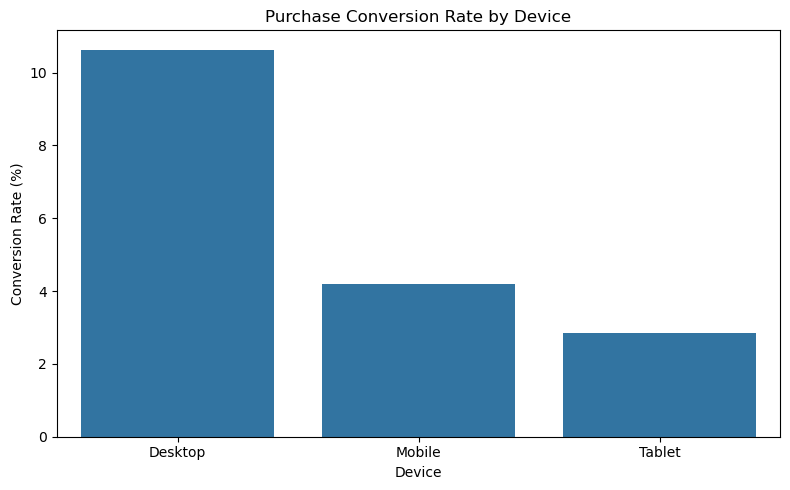

In [56]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_analysis,
    x="device",
    y="conversion_rate"
)

plt.title("Purchase Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

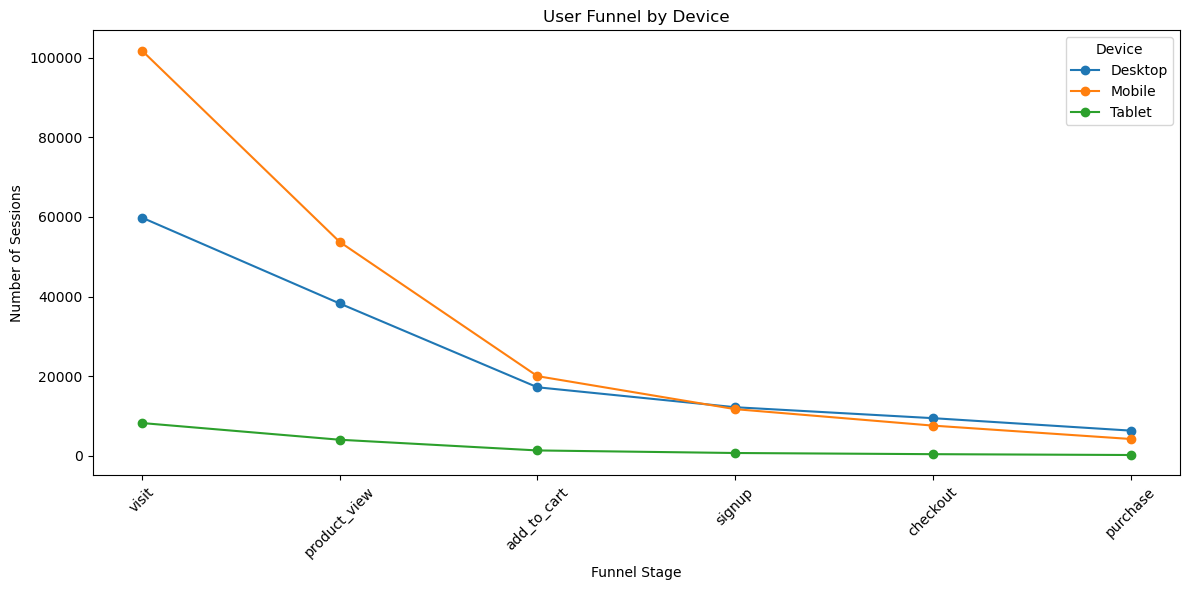

In [57]:
device_plot = device_funnel_summary.set_index(
    "device"
)[
    [
        "visit",
        "product_view",
        "add_to_cart",
        "signup",
        "checkout",
        "purchase"
    ]
]

device_plot.T.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("User Funnel by Device")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=45)

plt.legend(title="Device")

plt.tight_layout()

plt.show()

In [58]:
device_analysis

,device,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
0,Desktop,59820,38267,17236,12229,9483,6359,10.630224,6359,1.086675e+08,5501,17088.765388
1,Mobile,101754,53721,20030,11745,7613,4257,4.183619,4257,7.345866e+07,4018,17255.968548
2,Tablet,8260,4067,1380,738,445,235,2.845036,235,3.475479e+06,223,14789.273489


In [59]:
device_stage_results

,device,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Mobile,52.794976,37.285233,58.637044,64.819072,55.917510
1,Desktop,63.970244,45.041419,70.950337,77.545179,67.056839
2,Tablet,49.237288,33.931645,53.478261,60.298103,52.808989


In [63]:
mobile_desktop_comparison = pd.DataFrame({
    "metric": [
        "Visit → Product View",
        "Product View → Add to Cart",
        "Add to Cart → Signup",
        "Signup → Checkout",
        "Checkout → Purchase",
        "Overall Conversion"
    ],
    
    "Mobile": [
        device_stage_results.loc[
            device_stage_results["device"] == "Mobile",
            "visit_to_product_view"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Mobile",
            "product_view_to_add_to_cart"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Mobile",
            "add_to_cart_to_signup"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Mobile",
            "signup_to_checkout"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Mobile",
            "checkout_to_purchase"
        ].iloc[0],
        
        mobile_conversion
    ],
    
    "Desktop": [
        device_stage_results.loc[
            device_stage_results["device"] == "Desktop",
            "visit_to_product_view"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Desktop",
            "product_view_to_add_to_cart"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Desktop",
            "add_to_cart_to_signup"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Desktop",
            "signup_to_checkout"
        ].iloc[0],
        
        device_stage_results.loc[
            device_stage_results["device"] == "Desktop",
            "checkout_to_purchase"
        ].iloc[0],
        
        desktop_conversion
    ]
})

mobile_desktop_comparison["difference"] = (
    mobile_desktop_comparison["Desktop"]
    - mobile_desktop_comparison["Mobile"]
)

mobile_desktop_comparison

,metric,Mobile,Desktop,difference
0,Visit → Product View,52.794976,63.970244,11.175268
1,Product View → Add to Cart,37.285233,45.041419,7.756187
2,Add to Cart → Signup,58.637044,70.950337,12.313292
3,Signup → Checkout,64.819072,77.545179,12.726108
4,Checkout → Purchase,55.917510,67.056839,11.139329
5,Overall Conversion,4.183619,10.630224,6.446605


In [62]:
mobile_desktop_comparison.to_csv(
    "../data/processed/mobile_vs_desktop.csv",
    index=False
)

print("Mobile vs Desktop analysis saved!")

Mobile vs Desktop analysis saved!


In [64]:
traffic_funnel = (
    df.groupby(
        ["session_id", "traffic_source"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

traffic_funnel.head()

,session_id,traffic_source,event_type
0,S0000001,Google,{visit}
1,S0000002,Email,"{product_view, visit}"
2,S0000003,Direct,"{product_view, add_to_cart, visit}"
3,S0000004,Direct,"{product_view, visit}"
4,S0000005,Direct,"{product_view, visit}"


In [65]:
for stage in funnel_events:

    traffic_funnel[stage] = (
        traffic_funnel["event_type"]
        .apply(
            lambda x: int(stage in x)
        )
    )

In [66]:
traffic_funnel = traffic_funnel.drop(
    columns=["event_type"]
)

In [67]:
traffic_funnel.head()

,session_id,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,Google,1,0,0,0,0,0
1,S0000002,Email,1,1,0,0,0,0
2,S0000003,Direct,1,1,1,0,0,0
3,S0000004,Direct,1,1,0,0,0,0
4,S0000005,Direct,1,1,0,0,0,0


In [68]:
traffic_sources = [
    "Google",
    "Instagram",
    "Facebook",
    "YouTube",
    "Email",
    "Direct",
    "Referral",
    "Paid Ads"
]

print(traffic_sources)

['Google', 'Instagram', 'Facebook', 'YouTube', 'Email', 'Direct', 'Referral', 'Paid Ads']


In [69]:
traffic_funnel_summary = []

for source in traffic_sources:

    temp = traffic_funnel[
        traffic_funnel["traffic_source"] == source
    ]

    traffic_funnel_summary.append({
        "traffic_source": source,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

traffic_funnel_summary = pd.DataFrame(
    traffic_funnel_summary
)

traffic_funnel_summary

,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase
0,Google,33612,21813,9696,6196,4806,3131
1,Instagram,30789,14187,4599,2971,1650,768
2,Facebook,20427,8906,2673,1694,880,372
3,YouTube,13401,6650,2262,1490,889,413
4,Email,17214,12599,6559,4184,3546,2646
5,Direct,20231,13171,5820,3677,2827,1895
6,Referral,13327,7876,3095,1977,1384,823
7,Paid Ads,20833,10853,3942,2523,1559,803


In [70]:
traffic_funnel_summary["conversion_rate"] = (
    traffic_funnel_summary["purchase"]
    / traffic_funnel_summary["visit"]
    * 100
)

In [71]:
traffic_funnel_summary = (
    traffic_funnel_summary
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

In [72]:
traffic_funnel_summary

,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Email,17214,12599,6559,4184,3546,2646,15.371209
1,Direct,20231,13171,5820,3677,2827,1895,9.366813
2,Google,33612,21813,9696,6196,4806,3131,9.315126
3,Referral,13327,7876,3095,1977,1384,823,6.175433
4,Paid Ads,20833,10853,3942,2523,1559,803,3.854462
5,YouTube,13401,6650,2262,1490,889,413,3.081860
6,Instagram,30789,14187,4599,2971,1650,768,2.494397
7,Facebook,20427,8906,2673,1694,880,372,1.821119


In [73]:
traffic_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for source in traffic_sources:

    row = traffic_funnel_summary[
        traffic_funnel_summary["traffic_source"] == source
    ].iloc[0]

    result = {
        "traffic_source": source
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        previous_users = row[previous_stage]
        current_users = row[current_stage]

        conversion = (
            current_users
            / previous_users
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    traffic_stage_results.append(result)

traffic_stage_results = pd.DataFrame(
    traffic_stage_results
)

traffic_stage_results

,traffic_source,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Google,64.896466,44.450557,63.902640,77.566172,65.147732
1,Instagram,46.078145,32.417001,64.601000,55.536856,46.545455
2,Facebook,43.599158,30.013474,63.374486,51.948052,42.272727
3,YouTube,49.623162,34.015038,65.870911,59.664430,46.456693
4,Email,73.190426,52.059687,63.790212,84.751434,74.619289
5,Direct,65.103060,44.187989,63.178694,76.883329,67.032190
6,Referral,59.098072,39.296597,63.877221,70.005058,59.465318
7,Paid Ads,52.095234,36.321754,64.003044,61.791518,51.507377


In [74]:
for source in traffic_sources:

    row = traffic_stage_results[
        traffic_stage_results["traffic_source"] == source
    ].iloc[0]

    stage_columns = [
        col
        for col in traffic_stage_results.columns
        if col != "traffic_source"
    ]

    weakest_stage = row[
        stage_columns
    ].idxmin()

    weakest_rate = row[
        weakest_stage
    ]

    print(
        f"{source}: "
        f"{weakest_stage} = "
        f"{weakest_rate:.2f}%"
    )

Google: product_view_to_add_to_cart = 44.45%
Instagram: product_view_to_add_to_cart = 32.42%
Facebook: product_view_to_add_to_cart = 30.01%
YouTube: product_view_to_add_to_cart = 34.02%
Email: product_view_to_add_to_cart = 52.06%
Direct: product_view_to_add_to_cart = 44.19%
Referral: product_view_to_add_to_cart = 39.30%
Paid Ads: product_view_to_add_to_cart = 36.32%


In [75]:
traffic_revenue = (
    df[
        df["event_type"] == "purchase"
    ]
    .groupby("traffic_source")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

In [76]:
traffic_revenue["average_order_value"] = (
    traffic_revenue["revenue"]
    / traffic_revenue["orders"]
)

In [77]:
traffic_revenue

,traffic_source,orders,revenue,purchasers,average_order_value
0,Direct,1895,33827251.05,1683,17850.792111
1,Email,2646,45200650.61,2257,17082.634395
2,Facebook,372,6150060.08,356,16532.419570
3,Google,3131,51782101.59,2762,16538.518553
4,Instagram,768,12870974.70,742,16759.081641
5,Paid Ads,803,14200779.78,769,17684.657260
6,Referral,823,14246854.69,773,17310.880547
7,YouTube,413,7322923.98,400,17731.050799


In [78]:
traffic_analysis = traffic_funnel_summary.merge(
    traffic_revenue,
    on="traffic_source",
    how="left"
)

traffic_analysis

,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
0,Email,17214,12599,6559,4184,3546,2646,15.371209,2646,45200650.61,2257,17082.634395
1,Direct,20231,13171,5820,3677,2827,1895,9.366813,1895,33827251.05,1683,17850.792111
2,Google,33612,21813,9696,6196,4806,3131,9.315126,3131,51782101.59,2762,16538.518553
3,Referral,13327,7876,3095,1977,1384,823,6.175433,823,14246854.69,773,17310.880547
4,Paid Ads,20833,10853,3942,2523,1559,803,3.854462,803,14200779.78,769,17684.657260
5,YouTube,13401,6650,2262,1490,889,413,3.081860,413,7322923.98,400,17731.050799
6,Instagram,30789,14187,4599,2971,1650,768,2.494397,768,12870974.70,742,16759.081641
7,Facebook,20427,8906,2673,1694,880,372,1.821119,372,6150060.08,356,16532.419570


In [79]:
traffic_analysis.sort_values(
    "conversion_rate",
    ascending=False
)

,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
0,Email,17214,12599,6559,4184,3546,2646,15.371209,2646,45200650.61,2257,17082.634395
1,Direct,20231,13171,5820,3677,2827,1895,9.366813,1895,33827251.05,1683,17850.792111
2,Google,33612,21813,9696,6196,4806,3131,9.315126,3131,51782101.59,2762,16538.518553
3,Referral,13327,7876,3095,1977,1384,823,6.175433,823,14246854.69,773,17310.880547
4,Paid Ads,20833,10853,3942,2523,1559,803,3.854462,803,14200779.78,769,17684.657260
5,YouTube,13401,6650,2262,1490,889,413,3.081860,413,7322923.98,400,17731.050799
6,Instagram,30789,14187,4599,2971,1650,768,2.494397,768,12870974.70,742,16759.081641
7,Facebook,20427,8906,2673,1694,880,372,1.821119,372,6150060.08,356,16532.419570


In [80]:
highest_traffic_source = traffic_analysis.loc[
    traffic_analysis["visit"].idxmax()
]

print(
    "Highest Traffic Source:",
    highest_traffic_source["traffic_source"]
)

print(
    "Visitors:",
    f"{highest_traffic_source['visit']:,}"
)

Highest Traffic Source: Google
Visitors: 33,612


In [81]:
best_source = traffic_analysis.loc[
    traffic_analysis["conversion_rate"].idxmax()
]

print(
    "Best Converting Source:",
    best_source["traffic_source"]
)

print(
    f"Conversion Rate: "
    f"{best_source['conversion_rate']:.2f}%"
)

Best Converting Source: Email
Conversion Rate: 15.37%


In [82]:
worst_source = traffic_analysis.loc[
    traffic_analysis["conversion_rate"].idxmin()
]

print(
    "Lowest Converting Source:",
    worst_source["traffic_source"]
)

print(
    f"Conversion Rate: "
    f"{worst_source['conversion_rate']:.2f}%"
)

Lowest Converting Source: Facebook
Conversion Rate: 1.82%


In [83]:
median_traffic = traffic_analysis["visit"].median()

median_conversion = (
    traffic_analysis["conversion_rate"].median()
)

print(
    "Median Traffic:",
    f"{median_traffic:,.0f}"
)

print(
    "Median Conversion:",
    f"{median_conversion:.2f}%"
)

Median Traffic: 20,329
Median Conversion: 5.01%


In [84]:
high_traffic_low_conversion = traffic_analysis[
    (traffic_analysis["visit"] > median_traffic) &
    (traffic_analysis["conversion_rate"] < median_conversion)
]

high_traffic_low_conversion

,traffic_source,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
4,Paid Ads,20833,10853,3942,2523,1559,803,3.854462,803,14200779.78,769,17684.657260
6,Instagram,30789,14187,4599,2971,1650,768,2.494397,768,12870974.70,742,16759.081641
7,Facebook,20427,8906,2673,1694,880,372,1.821119,372,6150060.08,356,16532.419570


In [85]:
best_conversion = (
    traffic_analysis["conversion_rate"].max()
)

traffic_analysis["conversion_gap"] = (
    best_conversion
    - traffic_analysis["conversion_rate"]
)

traffic_analysis[
    [
        "traffic_source",
        "conversion_rate",
        "conversion_gap"
    ]
].sort_values(
    "conversion_gap",
    ascending=False
)

,traffic_source,conversion_rate,conversion_gap
7,Facebook,1.821119,13.550090
6,Instagram,2.494397,12.876812
5,YouTube,3.081860,12.289350
4,Paid Ads,3.854462,11.516748
3,Referral,6.175433,9.195776
2,Google,9.315126,6.056084
1,Direct,9.366813,6.004396
0,Email,15.371209,0.000000


In [86]:
traffic_analysis.to_csv(
    "../data/processed/traffic_source_analysis.csv",
    index=False
)

print("Traffic source analysis saved!")

Traffic source analysis saved!


In [87]:
traffic_stage_results.to_csv(
    "../data/processed/traffic_stage_conversion.csv",
    index=False
)

print("Traffic stage analysis saved!")

Traffic stage analysis saved!


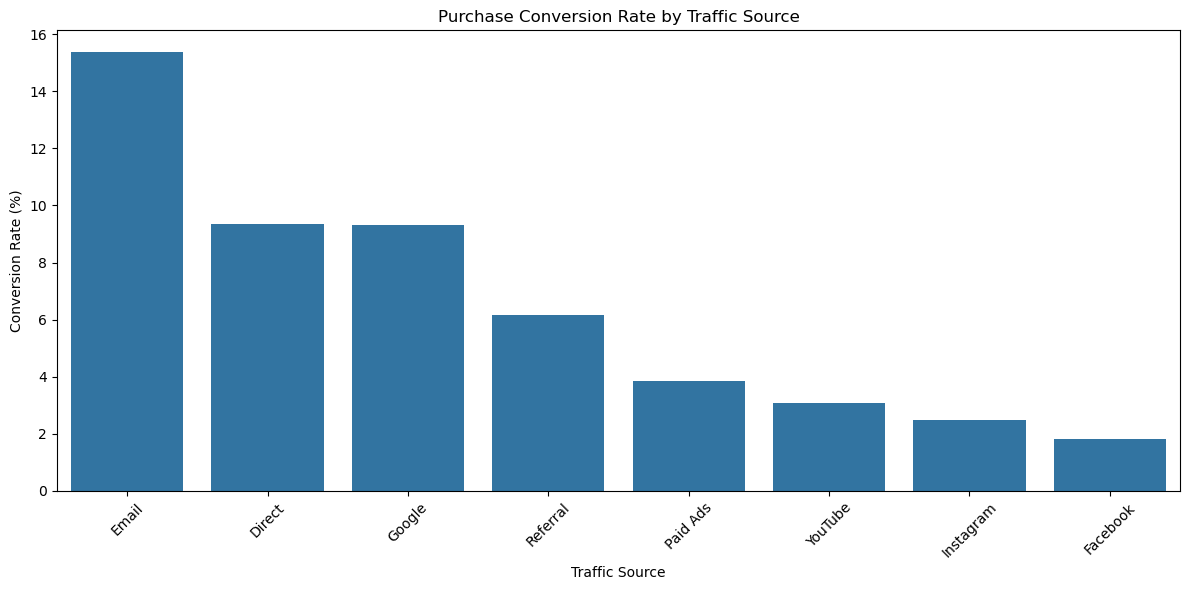

In [88]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=traffic_analysis.sort_values(
        "conversion_rate",
        ascending=False
    ),
    x="traffic_source",
    y="conversion_rate"
)

plt.title(
    "Purchase Conversion Rate by Traffic Source"
)

plt.xlabel("Traffic Source")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

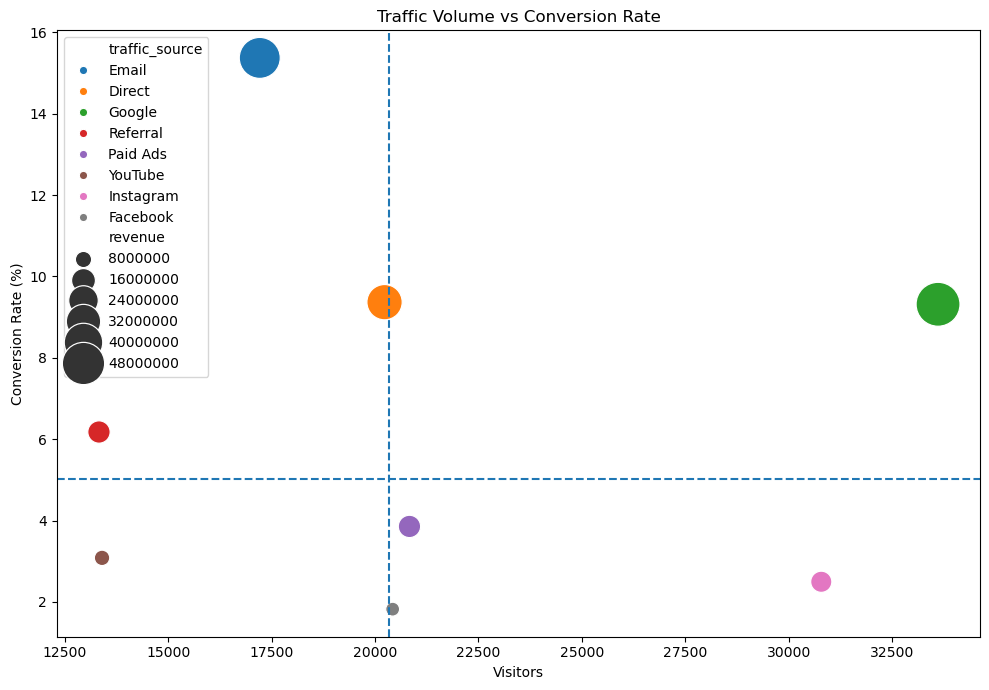

In [89]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=traffic_analysis,
    x="visit",
    y="conversion_rate",
    size="revenue",
    hue="traffic_source",
    sizes=(100, 1000)
)

plt.axvline(
    median_traffic,
    linestyle="--"
)

plt.axhline(
    median_conversion,
    linestyle="--"
)

plt.title(
    "Traffic Volume vs Conversion Rate"
)

plt.xlabel("Visitors")

plt.ylabel("Conversion Rate (%)")

plt.tight_layout()

plt.show()

In [90]:
marketing_opportunity = traffic_analysis[
    [
        "traffic_source",
        "visit",
        "purchase",
        "conversion_rate",
        "revenue",
        "average_order_value"
    ]
].sort_values(
    "visit",
    ascending=False
)

marketing_opportunity

,traffic_source,visit,purchase,conversion_rate,revenue,average_order_value
2,Google,33612,3131,9.315126,51782101.59,16538.518553
6,Instagram,30789,768,2.494397,12870974.70,16759.081641
4,Paid Ads,20833,803,3.854462,14200779.78,17684.657260
7,Facebook,20427,372,1.821119,6150060.08,16532.419570
1,Direct,20231,1895,9.366813,33827251.05,17850.792111
0,Email,17214,2646,15.371209,45200650.61,17082.634395
5,YouTube,13401,413,3.081860,7322923.98,17731.050799
3,Referral,13327,823,6.175433,14246854.69,17310.880547


In [91]:
marketing_opportunity.sort_values(
    "revenue",
    ascending=False
)

,traffic_source,visit,purchase,conversion_rate,revenue,average_order_value
2,Google,33612,3131,9.315126,51782101.59,16538.518553
0,Email,17214,2646,15.371209,45200650.61,17082.634395
1,Direct,20231,1895,9.366813,33827251.05,17850.792111
3,Referral,13327,823,6.175433,14246854.69,17310.880547
4,Paid Ads,20833,803,3.854462,14200779.78,17684.657260
6,Instagram,30789,768,2.494397,12870974.70,16759.081641
5,YouTube,13401,413,3.081860,7322923.98,17731.050799
7,Facebook,20427,372,1.821119,6150060.08,16532.419570


In [92]:
traffic_analysis["revenue_per_visitor"] = (
    traffic_analysis["revenue"]
    / traffic_analysis["visit"]
)

traffic_analysis[
    [
        "traffic_source",
        "visit",
        "conversion_rate",
        "revenue",
        "revenue_per_visitor"
    ]
].sort_values(
    "revenue_per_visitor",
    ascending=False
)

,traffic_source,visit,conversion_rate,revenue,revenue_per_visitor
0,Email,17214,15.371209,45200650.61,2625.807518
1,Direct,20231,9.366813,33827251.05,1672.050371
2,Google,33612,9.315126,51782101.59,1540.583767
3,Referral,13327,6.175433,14246854.69,1069.021887
4,Paid Ads,20833,3.854462,14200779.78,681.648336
5,YouTube,13401,3.081860,7322923.98,546.446085
6,Instagram,30789,2.494397,12870974.70,418.038088
7,Facebook,20427,1.821119,6150060.08,301.075052


In [93]:
traffic_analysis.to_csv(
    "../data/processed/traffic_source_analysis.csv",
    index=False
)

print("Enhanced traffic analysis saved!")

Enhanced traffic analysis saved!


In [94]:
location_funnel = (
    df.groupby(
        ["session_id", "location"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

location_funnel.head()

,session_id,location,event_type
0,S0000001,Pune,{visit}
1,S0000002,Ahmedabad,"{product_view, visit}"
2,S0000003,Chennai,"{product_view, add_to_cart, visit}"
3,S0000004,Kolkata,"{product_view, visit}"
4,S0000005,Kolkata,"{product_view, visit}"


In [95]:
for stage in funnel_events:

    location_funnel[stage] = (
        location_funnel["event_type"]
        .apply(lambda x: int(stage in x))
    )

In [96]:
location_funnel = location_funnel.drop(
    columns=["event_type"]
)

In [97]:
location_funnel.head()

,session_id,location,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,Pune,1,0,0,0,0,0
1,S0000002,Ahmedabad,1,1,0,0,0,0
2,S0000003,Chennai,1,1,1,0,0,0
3,S0000004,Kolkata,1,1,0,0,0,0
4,S0000005,Kolkata,1,1,0,0,0,0


In [98]:
locations = [
    "Mumbai",
    "Pune",
    "Delhi",
    "Bangalore",
    "Hyderabad",
    "Chennai",
    "Kolkata",
    "Ahmedabad"
]

print(locations)

['Mumbai', 'Pune', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai', 'Kolkata', 'Ahmedabad']


In [99]:
location_funnel_summary = []

for location in locations:

    temp = location_funnel[
        location_funnel["location"] == location
    ]

    location_funnel_summary.append({
        "location": location,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

location_funnel_summary = pd.DataFrame(
    location_funnel_summary
)

location_funnel_summary

,location,visit,product_view,add_to_cart,signup,checkout,purchase
0,Mumbai,21180,12051,4861,3126,2231,1379
1,Pune,21608,12327,4992,3194,2253,1377
2,Delhi,21217,12008,4839,3038,2138,1344
3,Bangalore,21075,11899,4833,3099,2220,1405
4,Hyderabad,21208,11882,4769,3070,2194,1335
5,Chennai,21192,11898,4768,3078,2180,1377
6,Kolkata,20954,11939,4758,3014,2101,1260
7,Ahmedabad,21400,12051,4826,3093,2224,1374


In [100]:
location_funnel_summary["conversion_rate"] = (
    location_funnel_summary["purchase"]
    / location_funnel_summary["visit"]
    * 100
)

In [101]:
location_funnel_summary = (
    location_funnel_summary
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

location_funnel_summary

,location,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Bangalore,21075,11899,4833,3099,2220,1405,6.666667
1,Mumbai,21180,12051,4861,3126,2231,1379,6.510859
2,Chennai,21192,11898,4768,3078,2180,1377,6.497735
3,Ahmedabad,21400,12051,4826,3093,2224,1374,6.420561
4,Pune,21608,12327,4992,3194,2253,1377,6.372640
5,Delhi,21217,12008,4839,3038,2138,1344,6.334543
6,Hyderabad,21208,11882,4769,3070,2194,1335,6.294794
7,Kolkata,20954,11939,4758,3014,2101,1260,6.013172


In [102]:
location_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for location in locations:

    row = location_funnel_summary[
        location_funnel_summary["location"] == location
    ].iloc[0]

    result = {
        "location": location
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        previous_users = row[previous_stage]
        current_users = row[current_stage]

        conversion = (
            current_users
            / previous_users
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    location_stage_results.append(result)

location_stage_results = pd.DataFrame(
    location_stage_results
)

location_stage_results

,location,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Mumbai,56.898017,40.336902,64.307756,71.369162,61.810847
1,Pune,57.048315,40.496471,63.982372,70.538510,61.118509
2,Delhi,56.596126,40.298135,62.781566,70.375247,62.862488
3,Bangalore,56.460261,40.616859,64.121664,71.636012,63.288288
4,Hyderabad,56.026028,40.136341,64.374083,71.465798,60.847767
5,Chennai,56.143828,40.073962,64.555369,70.825211,63.165138
6,Kolkata,56.977188,39.852584,63.345944,69.708029,59.971442
7,Ahmedabad,56.313084,40.046469,64.090344,71.904300,61.780576


In [103]:
for location in locations:

    row = location_stage_results[
        location_stage_results["location"] == location
    ].iloc[0]

    stage_columns = [
        col
        for col in location_stage_results.columns
        if col != "location"
    ]

    weakest_stage = row[
        stage_columns
    ].idxmin()

    weakest_rate = row[
        weakest_stage
    ]

    print(
        f"{location}: "
        f"{weakest_stage} = "
        f"{weakest_rate:.2f}%"
    )

Mumbai: product_view_to_add_to_cart = 40.34%
Pune: product_view_to_add_to_cart = 40.50%
Delhi: product_view_to_add_to_cart = 40.30%
Bangalore: product_view_to_add_to_cart = 40.62%
Hyderabad: product_view_to_add_to_cart = 40.14%
Chennai: product_view_to_add_to_cart = 40.07%
Kolkata: product_view_to_add_to_cart = 39.85%
Ahmedabad: product_view_to_add_to_cart = 40.05%


In [104]:
location_revenue = (
    df[
        df["event_type"] == "purchase"
    ]
    .groupby("location")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

In [105]:
location_revenue["average_order_value"] = (
    location_revenue["revenue"]
    / location_revenue["orders"]
)

In [106]:
location_revenue

,location,orders,revenue,purchasers,average_order_value
0,Ahmedabad,1374,23401020.10,1239,17031.310116
1,Bangalore,1405,23640524.28,1252,16825.995929
2,Chennai,1377,23699031.69,1254,17210.625773
3,Delhi,1344,22184332.36,1191,16506.199673
4,Hyderabad,1335,23966800.91,1205,17952.659858
5,Kolkata,1260,20738790.28,1130,16459.357365
6,Mumbai,1379,23943582.98,1245,17363.004336
7,Pune,1377,24027513.88,1226,17449.174931


In [107]:
location_analysis = location_funnel_summary.merge(
    location_revenue,
    on="location",
    how="left"
)

location_analysis

,location,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value
0,Bangalore,21075,11899,4833,3099,2220,1405,6.666667,1405,23640524.28,1252,16825.995929
1,Mumbai,21180,12051,4861,3126,2231,1379,6.510859,1379,23943582.98,1245,17363.004336
2,Chennai,21192,11898,4768,3078,2180,1377,6.497735,1377,23699031.69,1254,17210.625773
3,Ahmedabad,21400,12051,4826,3093,2224,1374,6.420561,1374,23401020.10,1239,17031.310116
4,Pune,21608,12327,4992,3194,2253,1377,6.372640,1377,24027513.88,1226,17449.174931
5,Delhi,21217,12008,4839,3038,2138,1344,6.334543,1344,22184332.36,1191,16506.199673
6,Hyderabad,21208,11882,4769,3070,2194,1335,6.294794,1335,23966800.91,1205,17952.659858
7,Kolkata,20954,11939,4758,3014,2101,1260,6.013172,1260,20738790.28,1130,16459.357365


In [108]:
location_analysis["revenue_per_visitor"] = (
    location_analysis["revenue"]
    / location_analysis["visit"]
)

In [109]:
location_analysis[
    [
        "location",
        "visit",
        "purchase",
        "conversion_rate",
        "revenue",
        "average_order_value",
        "revenue_per_visitor"
    ]
].sort_values(
    "conversion_rate",
    ascending=False
)

,location,visit,purchase,conversion_rate,revenue,average_order_value,revenue_per_visitor
0,Bangalore,21075,1405,6.666667,23640524.28,16825.995929,1121.733062
1,Mumbai,21180,1379,6.510859,23943582.98,17363.004336,1130.480783
2,Chennai,21192,1377,6.497735,23699031.69,17210.625773,1118.300854
3,Ahmedabad,21400,1374,6.420561,23401020.10,17031.310116,1093.505612
4,Pune,21608,1377,6.372640,24027513.88,17449.174931,1111.973060
5,Delhi,21217,1344,6.334543,22184332.36,16506.199673,1045.592325
6,Hyderabad,21208,1335,6.294794,23966800.91,17952.659858,1130.083030
7,Kolkata,20954,1260,6.013172,20738790.28,16459.357365,989.729421


In [110]:
best_location = location_analysis.loc[
    location_analysis["conversion_rate"].idxmax()
]

worst_location = location_analysis.loc[
    location_analysis["conversion_rate"].idxmin()
]

print("BEST LOCATION")
print("-------------")
print(
    best_location["location"],
    f"→ {best_location['conversion_rate']:.2f}%"
)

print("\nWORST LOCATION")
print("--------------")
print(
    worst_location["location"],
    f"→ {worst_location['conversion_rate']:.2f}%"
)

BEST LOCATION
-------------
Bangalore → 6.67%

WORST LOCATION
--------------
Kolkata → 6.01%


In [111]:
location_gap = (
    best_location["conversion_rate"]
    - worst_location["conversion_rate"]
)

print(
    f"Conversion gap: {location_gap:.2f} percentage points"
)

Conversion gap: 0.65 percentage points


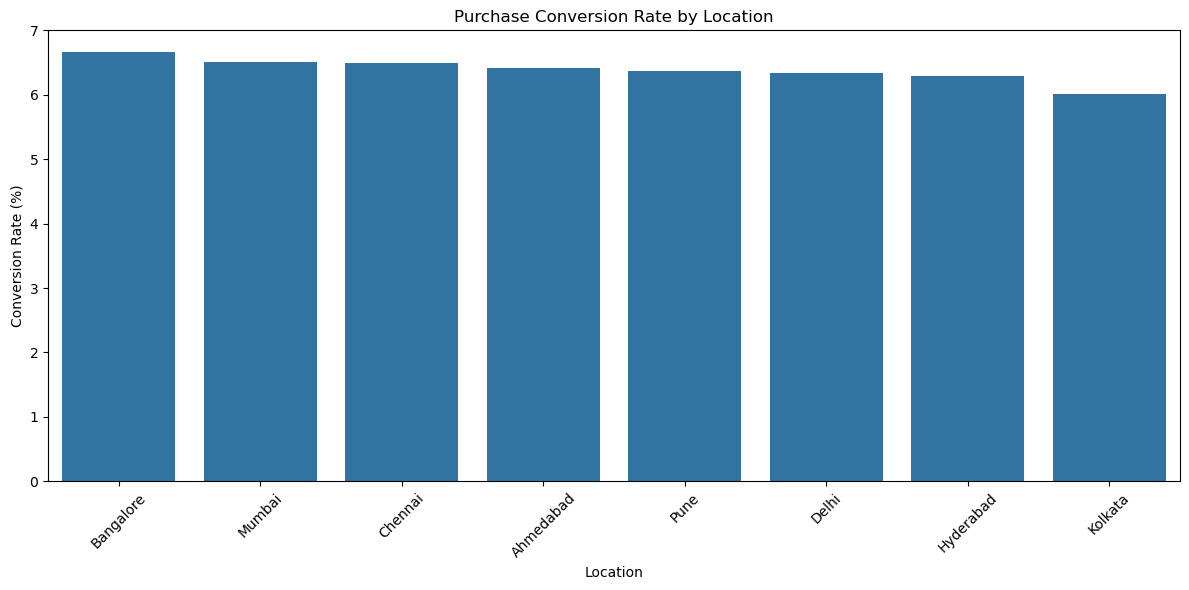

In [112]:
plt.figure(figsize=(12, 6))

plot_data = location_analysis.sort_values(
    "conversion_rate",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="location",
    y="conversion_rate"
)

plt.title(
    "Purchase Conversion Rate by Location"
)

plt.xlabel("Location")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

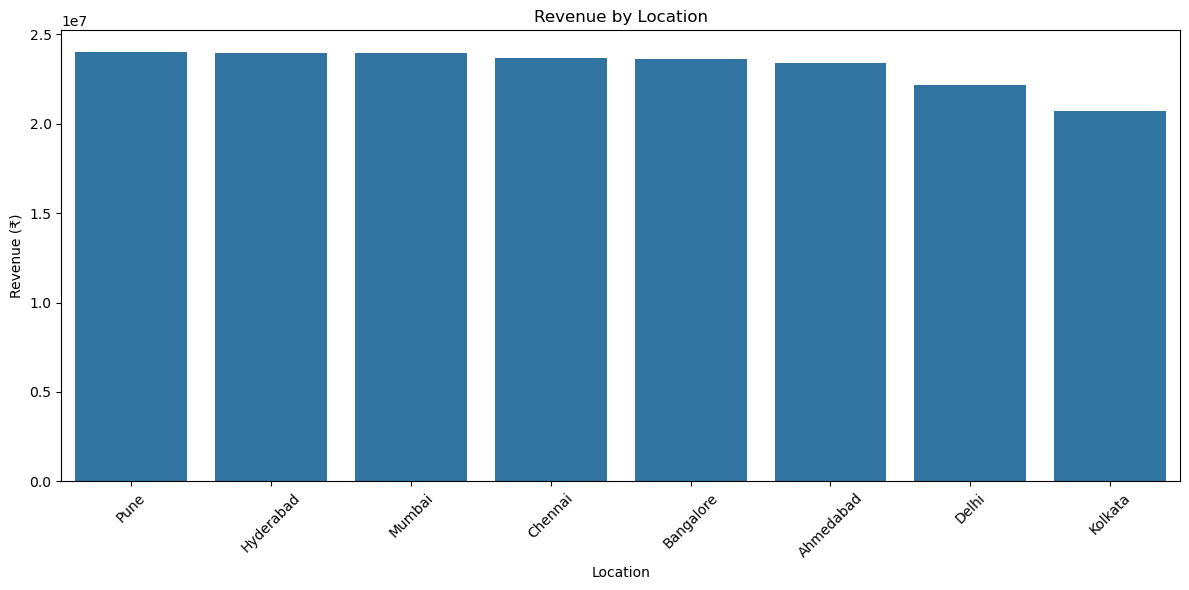

In [113]:
plt.figure(figsize=(12, 6))

plot_data = location_analysis.sort_values(
    "revenue",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="location",
    y="revenue"
)

plt.title(
    "Revenue by Location"
)

plt.xlabel("Location")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

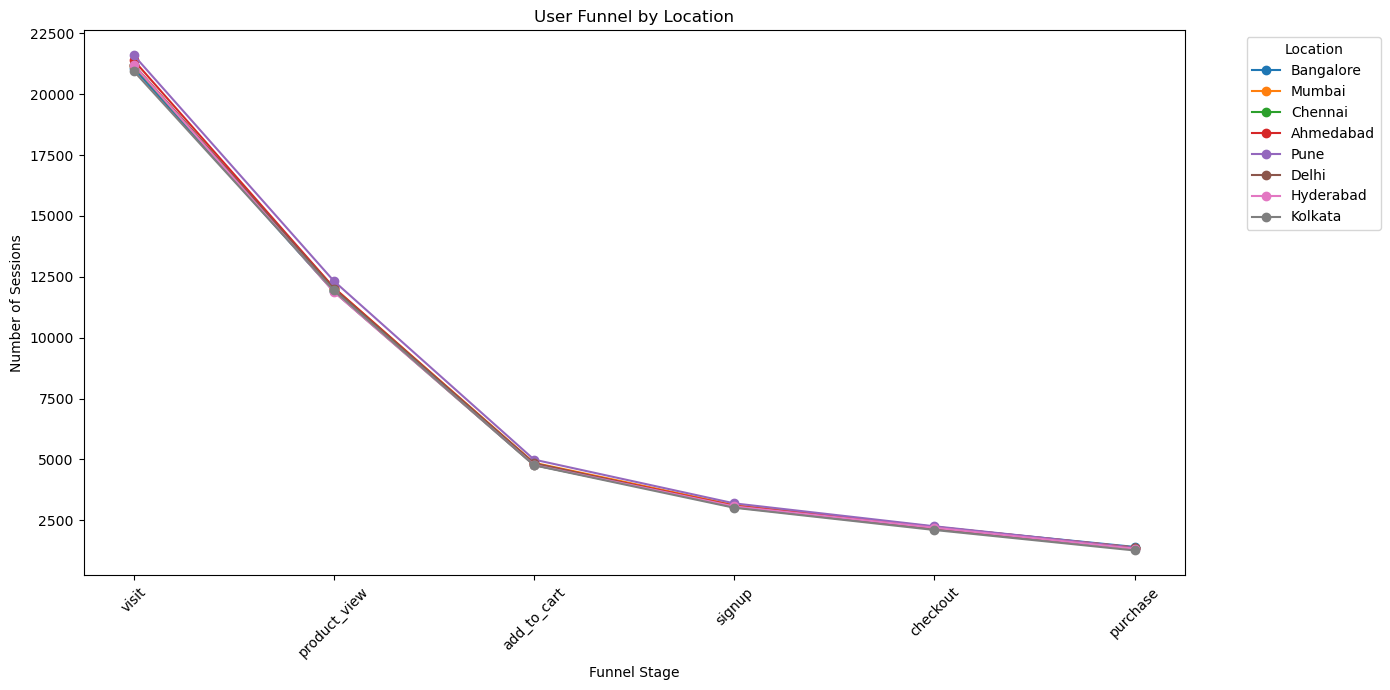

In [114]:
location_plot = location_funnel_summary.set_index(
    "location"
)[
    [
        "visit",
        "product_view",
        "add_to_cart",
        "signup",
        "checkout",
        "purchase"
    ]
]

location_plot.T.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title(
    "User Funnel by Location"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=45)

plt.legend(
    title="Location",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [115]:
location_analysis.to_csv(
    "../data/processed/location_analysis.csv",
    index=False
)

print("Location analysis saved!")

Location analysis saved!


In [116]:
location_stage_results.to_csv(
    "../data/processed/location_stage_conversion.csv",
    index=False
)

print("Location stage analysis saved!")

Location stage analysis saved!


In [117]:
stage_columns = [
    col
    for col in location_stage_results.columns
    if col != "location"
]

location_stage_average = (
    location_stage_results[stage_columns]
    .mean()
    .sort_values()
)

location_stage_average

product_view_to_add_to_cart    40.232215
visit_to_product_view          56.557856
checkout_to_purchase           61.855632
add_to_cart_to_signup          63.944887
signup_to_checkout             70.977784
dtype: float64

In [118]:
print(
    "Weakest average location funnel stage:"
)

print(
    location_stage_average.index[0],
    "→",
    f"{location_stage_average.iloc[0]:.2f}%"
)

Weakest average location funnel stage:
product_view_to_add_to_cart → 40.23%


In [119]:
location_stage_results

,location,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Mumbai,56.898017,40.336902,64.307756,71.369162,61.810847
1,Pune,57.048315,40.496471,63.982372,70.538510,61.118509
2,Delhi,56.596126,40.298135,62.781566,70.375247,62.862488
3,Bangalore,56.460261,40.616859,64.121664,71.636012,63.288288
4,Hyderabad,56.026028,40.136341,64.374083,71.465798,60.847767
5,Chennai,56.143828,40.073962,64.555369,70.825211,63.165138
6,Kolkata,56.977188,39.852584,63.345944,69.708029,59.971442
7,Ahmedabad,56.313084,40.046469,64.090344,71.904300,61.780576


In [120]:
customer_funnel = (
    df.groupby(
        ["session_id", "customer_type"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

customer_funnel.head()

,session_id,customer_type,event_type
0,S0000001,Returning,{visit}
1,S0000002,New,"{product_view, visit}"
2,S0000003,New,"{product_view, add_to_cart, visit}"
3,S0000004,New,"{product_view, visit}"
4,S0000005,New,"{product_view, visit}"


In [121]:
           for stage in funnel_events:

    customer_funnel[stage] = (
        customer_funnel["event_type"]
        .apply(lambda x: int(stage in x))
    )

customer_funnel = customer_funnel.drop(
    columns=["event_type"]
)

customer_funnel.head()

,session_id,customer_type,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000001,Returning,1,0,0,0,0,0
1,S0000002,New,1,1,0,0,0,0
2,S0000003,New,1,1,1,0,0,0
3,S0000004,New,1,1,0,0,0,0
4,S0000005,New,1,1,0,0,0,0


In [122]:
customer_types = [
    "New",
    "Returning"
]

customer_funnel_summary = []

for customer_type in customer_types:

    temp = customer_funnel[
        customer_funnel["customer_type"] == customer_type
    ]

    customer_funnel_summary.append({
        "customer_type": customer_type,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

customer_funnel_summary = pd.DataFrame(
    customer_funnel_summary
)

customer_funnel_summary

,customer_type,visit,product_view,add_to_cart,signup,checkout,purchase
0,New,127380,65499,23375,12916,7732,3866
1,Returning,42454,30556,15271,11796,9809,6985


In [123]:
customer_funnel_summary["conversion_rate"] = (
    customer_funnel_summary["purchase"]
    / customer_funnel_summary["visit"]
    * 100
)

customer_funnel_summary

,customer_type,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,New,127380,65499,23375,12916,7732,3866,3.035013
1,Returning,42454,30556,15271,11796,9809,6985,16.453102


In [124]:
customer_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for customer_type in customer_types:

    row = customer_funnel_summary[
        customer_funnel_summary["customer_type"] == customer_type
    ].iloc[0]

    result = {
        "customer_type": customer_type
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        conversion = (
            row[current_stage]
            / row[previous_stage]
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    customer_stage_results.append(result)

customer_stage_results = pd.DataFrame(
    customer_stage_results
)

customer_stage_results

,customer_type,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,New,51.420160,35.687568,55.255615,59.863735,50.000000
1,Returning,71.974372,49.977091,77.244450,83.155307,71.210113


In [125]:
customer_revenue = (
    df[
        df["event_type"] == "purchase"
    ]
    .groupby("customer_type")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

customer_revenue["average_order_value"] = (
    customer_revenue["revenue"]
    / customer_revenue["orders"]
)

customer_revenue

,customer_type,orders,revenue,purchasers,average_order_value
0,New,3866,6.525909e+07,3736,16880.260059
1,Returning,6985,1.203425e+08,6006,17228.705954


In [126]:
customer_analysis = customer_funnel_summary.merge(
    customer_revenue,
    on="customer_type",
    how="left"
)

customer_analysis["revenue_per_visitor"] = (
    customer_analysis["revenue"]
    / customer_analysis["visit"]
)

customer_analysis

,customer_type,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value,revenue_per_visitor
0,New,127380,65499,23375,12916,7732,3866,3.035013,3866,6.525909e+07,3736,16880.260059,512.318146
1,Returning,42454,30556,15271,11796,9809,6985,16.453102,6985,1.203425e+08,6006,17228.705954,2834.656595


In [127]:
customer_analysis.to_csv(
    "../data/processed/customer_type_analysis.csv",
    index=False
)

customer_stage_results.to_csv(
    "../data/processed/customer_stage_conversion.csv",
    index=False
)

print("Customer analysis saved!")

Customer analysis saved!


In [128]:
customer_stage_results

,customer_type,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,New,51.420160,35.687568,55.255615,59.863735,50.000000
1,Returning,71.974372,49.977091,77.244450,83.155307,71.210113


In [129]:
new_conversion = customer_analysis.loc[
    customer_analysis["customer_type"] == "New",
    "conversion_rate"
].iloc[0]

returning_conversion = customer_analysis.loc[
    customer_analysis["customer_type"] == "Returning",
    "conversion_rate"
].iloc[0]

conversion_difference = (
    returning_conversion
    - new_conversion
)

conversion_multiplier = (
    returning_conversion
    / new_conversion
)

print(
    f"New Customer Conversion: "
    f"{new_conversion:.2f}%"
)

print(
    f"Returning Customer Conversion: "
    f"{returning_conversion:.2f}%"
)

print(
    f"Conversion Difference: "
    f"{conversion_difference:.2f} percentage points"
)

print(
    f"Returning customers convert "
    f"{conversion_multiplier:.2f}x more"
)

New Customer Conversion: 3.04%
Returning Customer Conversion: 16.45%
Conversion Difference: 13.42 percentage points
Returning customers convert 5.42x more


In [130]:
customer_analysis[
    [
        "customer_type",
        "visit",
        "conversion_rate",
        "revenue",
        "average_order_value",
        "revenue_per_visitor"
    ]
]

,customer_type,visit,conversion_rate,revenue,average_order_value,revenue_per_visitor
0,New,127380,3.035013,6.525909e+07,16880.260059,512.318146
1,Returning,42454,16.453102,1.203425e+08,17228.705954,2834.656595


In [131]:
customer_analysis.to_csv(
    "../data/processed/customer_type_analysis.csv",
    index=False
)

print("Customer analysis saved successfully!")

Customer analysis saved successfully!


In [132]:
customer_stage_results

,customer_type,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,New,51.420160,35.687568,55.255615,59.863735,50.000000
1,Returning,71.974372,49.977091,77.244450,83.155307,71.210113


In [133]:
df["product_category"].value_counts()

product_category
Fashion        37916
Beauty         37691
Sports         37551
Home           37431
Electronics    37216
Name: count, dtype: int64

In [134]:
print(
    "Product Categories:",
    df["product_category"].unique()
)

Product Categories: [nan 'Sports' 'Electronics' 'Home' 'Fashion' 'Beauty']


In [135]:
category_funnel = (
    df.groupby(
        ["session_id", "product_category"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

category_funnel.head()

,session_id,product_category,event_type
0,S0000002,Sports,{product_view}
1,S0000003,Electronics,"{product_view, add_to_cart}"
2,S0000004,Sports,{product_view}
3,S0000005,Home,{product_view}
4,S0000009,Home,"{product_view, signup, checkout, add_to_cart}"


In [136]:
for stage in funnel_events:

    category_funnel[stage] = (
        category_funnel["event_type"]
        .apply(lambda x: int(stage in x))
    )

category_funnel = category_funnel.drop(
    columns=["event_type"]
)

category_funnel.head()

,session_id,product_category,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000002,Sports,0,1,0,0,0,0
1,S0000003,Electronics,0,1,1,0,0,0
2,S0000004,Sports,0,1,0,0,0,0
3,S0000005,Home,0,1,0,0,0,0
4,S0000009,Home,0,1,1,1,1,0


In [137]:
categories = sorted(
    category_funnel["product_category"]
    .dropna()
    .unique()
)

print("Categories:")
print(categories)

Categories:
['Beauty', 'Electronics', 'Fashion', 'Home', 'Sports']


In [138]:
category_funnel_summary = []

for category in categories:

    temp = category_funnel[
        category_funnel["product_category"] == category
    ]

    category_funnel_summary.append({
        "product_category": category,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

category_funnel_summary = pd.DataFrame(
    category_funnel_summary
)

category_funnel_summary

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase
0,Beauty,0,19159,7845,4936,3559,2192
1,Electronics,0,19253,7639,4846,3382,2096
2,Fashion,0,19414,7793,5005,3520,2184
3,Home,0,19137,7723,4936,3480,2155
4,Sports,0,19092,7646,4989,3600,2224


In [139]:
category_funnel_summary["conversion_rate"] = (
    category_funnel_summary["purchase"]
    / category_funnel_summary["visit"]
    * 100
)

category_funnel_summary = (
    category_funnel_summary
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

category_funnel_summary

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Beauty,0,19159,7845,4936,3559,2192,inf
1,Electronics,0,19253,7639,4846,3382,2096,inf
2,Fashion,0,19414,7793,5005,3520,2184,inf
3,Home,0,19137,7723,4936,3480,2155,inf
4,Sports,0,19092,7646,4989,3600,2224,inf


In [140]:
category_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for category in categories:

    row = category_funnel_summary[
        category_funnel_summary["product_category"] == category
    ].iloc[0]

    result = {
        "product_category": category
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        conversion = (
            row[current_stage]
            / row[previous_stage]
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    category_stage_results.append(result)

category_stage_results = pd.DataFrame(
    category_stage_results
)

category_stage_results

C:\Users\91801\AppData\Local\Temp\ipykernel_10624\901454276.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  row[current_stage]


,product_category,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Beauty,inf,40.946814,62.919057,72.102917,61.590334
1,Electronics,inf,39.676933,63.437623,69.789517,61.975163
2,Fashion,inf,40.141135,64.224304,70.329670,62.045455
3,Home,inf,40.356378,63.912987,70.502431,61.925287
4,Sports,inf,40.048188,65.249804,72.158749,61.777778


In [141]:
category_revenue = (
    df[
        df["event_type"] == "purchase"
    ]
    .groupby("product_category")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

In [142]:
category_revenue["average_order_value"] = (
    category_revenue["revenue"]
    / category_revenue["orders"]
)

In [143]:
category_revenue

,product_category,orders,revenue,purchasers,average_order_value
0,Beauty,2192,9.235842e+06,2139,4213.431661
1,Electronics,2096,1.087532e+08,2048,51886.062863
2,Fashion,2184,1.150265e+07,2127,5266.779313
3,Home,2155,3.361732e+07,2107,15599.684923
4,Sports,2224,2.249260e+07,2162,10113.578907


In [144]:
category_analysis = category_funnel_summary.merge(
    category_revenue,
    on="product_category",
    how="left"
)

category_analysis["revenue_per_visitor"] = (
    category_analysis["revenue"]
    / category_analysis["visit"]
)

category_analysis

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value,revenue_per_visitor
0,Beauty,0,19159,7845,4936,3559,2192,inf,2192,9.235842e+06,2139,4213.431661,inf
1,Electronics,0,19253,7639,4846,3382,2096,inf,2096,1.087532e+08,2048,51886.062863,inf
2,Fashion,0,19414,7793,5005,3520,2184,inf,2184,1.150265e+07,2127,5266.779313,inf
3,Home,0,19137,7723,4936,3480,2155,inf,2155,3.361732e+07,2107,15599.684923,inf
4,Sports,0,19092,7646,4989,3600,2224,inf,2224,2.249260e+07,2162,10113.578907,inf


In [145]:
best_category = category_analysis.loc[
    category_analysis["conversion_rate"].idxmax()
]

worst_category = category_analysis.loc[
    category_analysis["conversion_rate"].idxmin()
]

print("BEST CATEGORY")
print("-------------")
print(
    best_category["product_category"],
    f"→ {best_category['conversion_rate']:.2f}%"
)

print("\nWORST CATEGORY")
print("--------------")
print(
    worst_category["product_category"],
    f"→ {worst_category['conversion_rate']:.2f}%"
)

BEST CATEGORY
-------------
Beauty → inf%

WORST CATEGORY
--------------
Beauty → inf%


In [146]:
for category in categories:

    row = category_stage_results[
        category_stage_results["product_category"] == category
    ].iloc[0]

    stage_columns = [
        col
        for col in category_stage_results.columns
        if col != "product_category"
    ]

    weakest_stage = row[
        stage_columns
    ].idxmin()

    weakest_rate = row[
        weakest_stage
    ]

    print(
        f"{category}: "
        f"{weakest_stage} = "
        f"{weakest_rate:.2f}%"
    )

Beauty: product_view_to_add_to_cart = 40.95%
Electronics: product_view_to_add_to_cart = 39.68%
Fashion: product_view_to_add_to_cart = 40.14%
Home: product_view_to_add_to_cart = 40.36%
Sports: product_view_to_add_to_cart = 40.05%


In [147]:
category_analysis.to_csv(
    "../data/processed/product_category_analysis.csv",
    index=False
)

category_stage_results.to_csv(
    "../data/processed/category_stage_conversion.csv",
    index=False
)

print("Product category analysis saved!")

Product category analysis saved!


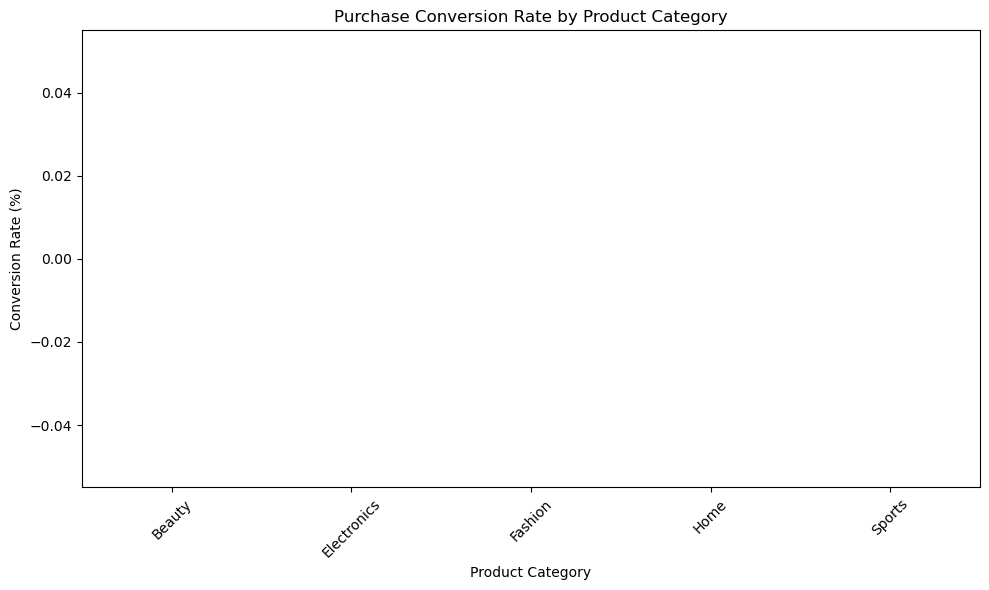

In [148]:
plt.figure(figsize=(10, 6))

plot_data = category_analysis.sort_values(
    "conversion_rate",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="product_category",
    y="conversion_rate"
)

plt.title(
    "Purchase Conversion Rate by Product Category"
)

plt.xlabel("Product Category")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [149]:
session_category = (
    df[df["product_category"].notna()]
    .sort_values("event_timestamp")
    .groupby("session_id")["product_category"]
    .first()
    .reset_index()
)

session_category.head()

,session_id,product_category
0,S0000002,Sports
1,S0000003,Electronics
2,S0000004,Sports
3,S0000005,Home
4,S0000009,Home


In [150]:
print(
    "Total sessions:",
    df["session_id"].nunique()
)

print(
    "Sessions with category:",
    session_category["session_id"].nunique()
)

Total sessions: 169834
Sessions with category: 96055


In [151]:
df_category = df.drop(
    columns=["product_category"]
).merge(
    session_category,
    on="session_id",
    how="left"
)

In [152]:
df_category[
    [
        "session_id",
        "event_type",
        "product_category"
    ]
].head(20)

,session_id,event_type,product_category
0,S0000001,visit,NaN
1,S0000002,visit,Sports
2,S0000002,product_view,Sports
3,S0000003,visit,Electronics
4,S0000003,product_view,Electronics
5,S0000003,add_to_cart,Electronics
6,S0000004,visit,Sports
7,S0000004,product_view,Sports
8,S0000005,visit,Home
9,S0000005,product_view,Home


In [153]:
category_funnel = (
    df_category.groupby(
        ["session_id", "product_category"]
    )["event_type"]
    .apply(set)
    .reset_index()
)

In [154]:
for stage in funnel_events:

    category_funnel[stage] = (
        category_funnel["event_type"]
        .apply(lambda x: int(stage in x))
    )

In [155]:
category_funnel = category_funnel.drop(
    columns=["event_type"]
)

In [156]:
category_funnel.head()

,session_id,product_category,visit,product_view,add_to_cart,signup,checkout,purchase
0,S0000002,Sports,1,1,0,0,0,0
1,S0000003,Electronics,1,1,1,0,0,0
2,S0000004,Sports,1,1,0,0,0,0
3,S0000005,Home,1,1,0,0,0,0
4,S0000009,Home,1,1,1,1,1,0


In [157]:
categories = sorted(
    category_funnel["product_category"]
    .dropna()
    .unique()
)

category_funnel_summary = []

for category in categories:

    temp = category_funnel[
        category_funnel["product_category"] == category
    ]

    category_funnel_summary.append({
        "product_category": category,
        "visit": temp["visit"].sum(),
        "product_view": temp["product_view"].sum(),
        "add_to_cart": temp["add_to_cart"].sum(),
        "signup": temp["signup"].sum(),
        "checkout": temp["checkout"].sum(),
        "purchase": temp["purchase"].sum()
    })

category_funnel_summary = pd.DataFrame(
    category_funnel_summary
)

category_funnel_summary

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase
0,Beauty,19159,19159,7845,4936,3559,2192
1,Electronics,19253,19253,7639,4846,3382,2096
2,Fashion,19414,19414,7793,5005,3520,2184
3,Home,19137,19137,7723,4936,3480,2155
4,Sports,19092,19092,7646,4989,3600,2224


In [158]:
category_funnel_summary["conversion_rate"] = (
    category_funnel_summary["purchase"]
    / category_funnel_summary["visit"]
    * 100
)

category_funnel_summary = (
    category_funnel_summary
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

category_funnel_summary

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate
0,Sports,19092,19092,7646,4989,3600,2224,11.648858
1,Beauty,19159,19159,7845,4936,3559,2192,11.441098
2,Home,19137,19137,7723,4936,3480,2155,11.260908
3,Fashion,19414,19414,7793,5005,3520,2184,11.249614
4,Electronics,19253,19253,7639,4846,3382,2096,10.886615


In [159]:
print(
    "Zero visit categories:",
    (
        category_funnel_summary["visit"] == 0
    ).sum()
)

print(
    "Infinite conversion values:",
    np.isinf(
        category_funnel_summary["conversion_rate"]
    ).sum()
)

print(
    "Missing conversion values:",
    category_funnel_summary[
        "conversion_rate"
    ].isna().sum()
)

Zero visit categories: 0
Infinite conversion values: 0
Missing conversion values: 0


In [160]:
category_stage_results = []

stages = [
    "visit",
    "product_view",
    "add_to_cart",
    "signup",
    "checkout",
    "purchase"
]

for category in categories:

    row = category_funnel_summary[
        category_funnel_summary["product_category"] == category
    ].iloc[0]

    result = {
        "product_category": category
    }

    for i in range(1, len(stages)):

        previous_stage = stages[i - 1]
        current_stage = stages[i]

        previous_users = row[previous_stage]
        current_users = row[current_stage]

        conversion = (
            current_users
            / previous_users
            * 100
        )

        result[
            f"{previous_stage}_to_{current_stage}"
        ] = conversion

    category_stage_results.append(result)

category_stage_results = pd.DataFrame(
    category_stage_results
)

category_stage_results

,product_category,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Beauty,100.0,40.946814,62.919057,72.102917,61.590334
1,Electronics,100.0,39.676933,63.437623,69.789517,61.975163
2,Fashion,100.0,40.141135,64.224304,70.329670,62.045455
3,Home,100.0,40.356378,63.912987,70.502431,61.925287
4,Sports,100.0,40.048188,65.249804,72.158749,61.777778


In [161]:
category_revenue = (
    df_category[
        df_category["event_type"] == "purchase"
    ]
    .groupby("product_category")
    .agg(
        orders=("event_id", "count"),
        revenue=("amount", "sum"),
        purchasers=("user_id", "nunique")
    )
    .reset_index()
)

category_revenue["average_order_value"] = (
    category_revenue["revenue"]
    / category_revenue["orders"]
)

category_revenue

,product_category,orders,revenue,purchasers,average_order_value
0,Beauty,2192,9.235842e+06,2139,4213.431661
1,Electronics,2096,1.087532e+08,2048,51886.062863
2,Fashion,2184,1.150265e+07,2127,5266.779313
3,Home,2155,3.361732e+07,2107,15599.684923
4,Sports,2224,2.249260e+07,2162,10113.578907


In [162]:
category_analysis = category_funnel_summary.merge(
    category_revenue,
    on="product_category",
    how="left"
)

category_analysis["revenue_per_visitor"] = (
    category_analysis["revenue"]
    / category_analysis["visit"]
)

category_analysis

,product_category,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value,revenue_per_visitor
0,Sports,19092,19092,7646,4989,3600,2224,11.648858,2224,2.249260e+07,2162,10113.578907,1178.116462
1,Beauty,19159,19159,7845,4936,3559,2192,11.441098,2192,9.235842e+06,2139,4213.431661,482.062853
2,Home,19137,19137,7723,4936,3480,2155,11.260908,2155,3.361732e+07,2107,15599.684923,1756.666197
3,Fashion,19414,19414,7793,5005,3520,2184,11.249614,2184,1.150265e+07,2127,5266.779313,592.492326
4,Electronics,19253,19253,7639,4846,3382,2096,10.886615,2096,1.087532e+08,2048,51886.062863,5648.635940


In [163]:
category_analysis.to_csv(
    "../data/processed/product_category_analysis.csv",
    index=False
)

category_stage_results.to_csv(
    "../data/processed/category_stage_conversion.csv",
    index=False
)

print("Corrected category analysis saved successfully!")

Corrected category analysis saved successfully!


In [164]:
category_analysis


,product_category,visit,product_view,add_to_cart,signup,checkout,purchase,conversion_rate,orders,revenue,purchasers,average_order_value,revenue_per_visitor
0,Sports,19092,19092,7646,4989,3600,2224,11.648858,2224,2.249260e+07,2162,10113.578907,1178.116462
1,Beauty,19159,19159,7845,4936,3559,2192,11.441098,2192,9.235842e+06,2139,4213.431661,482.062853
2,Home,19137,19137,7723,4936,3480,2155,11.260908,2155,3.361732e+07,2107,15599.684923,1756.666197
3,Fashion,19414,19414,7793,5005,3520,2184,11.249614,2184,1.150265e+07,2127,5266.779313,592.492326
4,Electronics,19253,19253,7639,4846,3382,2096,10.886615,2096,1.087532e+08,2048,51886.062863,5648.635940


In [165]:
category_stage_results

,product_category,visit_to_product_view,product_view_to_add_to_cart,add_to_cart_to_signup,signup_to_checkout,checkout_to_purchase
0,Beauty,100.0,40.946814,62.919057,72.102917,61.590334
1,Electronics,100.0,39.676933,63.437623,69.789517,61.975163
2,Fashion,100.0,40.141135,64.224304,70.329670,62.045455
3,Home,100.0,40.356378,63.912987,70.502431,61.925287
4,Sports,100.0,40.048188,65.249804,72.158749,61.777778


In [166]:
segment_base = (
    df.sort_values("event_timestamp")
    .groupby("session_id")
    .first()
    .reset_index()
)

segment_base = segment_base[
    [
        "session_id",
        "user_id",
        "device",
        "traffic_source",
        "location",
        "customer_type"
    ]
]

segment_base.head()

,session_id,user_id,device,traffic_source,location,customer_type
0,S0000001,U000001,Mobile,Google,Pune,Returning
1,S0000002,U000002,Tablet,Email,Ahmedabad,New
2,S0000003,U000003,Desktop,Direct,Chennai,New
3,S0000004,U000004,Mobile,Direct,Kolkata,New
4,S0000005,U000004,Mobile,Direct,Kolkata,New


In [167]:
session_purchase = (
    df.groupby("session_id")["event_type"]
    .apply(lambda x: int("purchase" in set(x)))
    .reset_index(name="purchased")
)

In [168]:
segment_base = segment_base.merge(
    session_purchase,
    on="session_id",
    how="left"
)

segment_base.head()

,session_id,user_id,device,traffic_source,location,customer_type,purchased
0,S0000001,U000001,Mobile,Google,Pune,Returning,0
1,S0000002,U000002,Tablet,Email,Ahmedabad,New,0
2,S0000003,U000003,Desktop,Direct,Chennai,New,0
3,S0000004,U000004,Mobile,Direct,Kolkata,New,0
4,S0000005,U000004,Mobile,Direct,Kolkata,New,0


In [169]:
device_traffic = (
    segment_base
    .groupby(
        ["device", "traffic_source"]
    )
    .agg(
        sessions=("session_id", "count"),
        purchases=("purchased", "sum")
    )
    .reset_index()
)

In [170]:
device_traffic["conversion_rate"] = (
    device_traffic["purchases"]
    / device_traffic["sessions"]
    * 100
)

In [171]:
device_traffic = device_traffic.sort_values(
    "conversion_rate"
)

device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
23,Tablet,YouTube,668,11,1.646707
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
22,Tablet,Referral,615,16,2.601626
2,Desktop,Facebook,7190,228,3.171071


In [172]:
meaningful_device_traffic = device_traffic[
    device_traffic["sessions"] >= 1000
].copy()

meaningful_device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
2,Desktop,Facebook,7190,228,3.171071
19,Tablet,Google,1643,64,3.895313
14,Mobile,Referral,8131,335,4.120034


In [173]:
worst_device_traffic = (
    meaningful_device_traffic
    .sort_values("conversion_rate")
    .head(10)
)

worst_device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
2,Desktop,Facebook,7190,228,3.171071
19,Tablet,Google,1643,64,3.895313
14,Mobile,Referral,8131,335,4.120034


In [174]:
best_device_traffic = (
    meaningful_device_traffic
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .head(10)
)

best_device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
1,Desktop,Email,6237,1524,24.434824
3,Desktop,Google,11853,1853,15.633173
0,Desktop,Direct,7110,1097,15.428973
9,Mobile,Email,10168,1068,10.503541
6,Desktop,Referral,4581,472,10.303427
5,Desktop,Paid Ads,7259,471,6.488497
8,Mobile,Direct,12139,754,6.211385
11,Mobile,Google,20116,1214,6.034997
7,Desktop,YouTube,4609,240,5.207203
4,Desktop,Instagram,10981,474,4.316547


In [175]:
device_traffic.to_csv(
    "../data/processed/device_traffic_analysis.csv",
    index=False
)

print("Device × Traffic Source analysis saved!")

Device × Traffic Source analysis saved!


In [176]:
device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
23,Tablet,YouTube,668,11,1.646707
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
22,Tablet,Referral,615,16,2.601626
2,Desktop,Facebook,7190,228,3.171071


In [177]:
meaningful_device_traffic

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
2,Desktop,Facebook,7190,228,3.171071
19,Tablet,Google,1643,64,3.895313
14,Mobile,Referral,8131,335,4.120034


In [178]:
meaningful_device_traffic.sort_values(
    "conversion_rate"
).head(10)

,device,traffic_source,sessions,purchases,conversion_rate
18,Tablet,Facebook,1033,8,0.774443
20,Tablet,Instagram,1483,15,1.011463
10,Mobile,Facebook,12204,136,1.114389
12,Mobile,Instagram,18325,279,1.522510
15,Mobile,YouTube,8124,162,1.994092
21,Tablet,Paid Ads,1027,23,2.239533
13,Mobile,Paid Ads,12547,309,2.462740
2,Desktop,Facebook,7190,228,3.171071
19,Tablet,Google,1643,64,3.895313
14,Mobile,Referral,8131,335,4.120034


In [179]:
device_traffic_customer = (
    segment_base
    .groupby(
        [
            "device",
            "traffic_source",
            "customer_type"
        ]
    )
    .agg(
        sessions=("session_id", "count"),
        purchases=("purchased", "sum")
    )
    .reset_index()
)

In [180]:
device_traffic_customer["conversion_rate"] = (
    device_traffic_customer["purchases"]
    / device_traffic_customer["sessions"]
    * 100
)

In [181]:
meaningful_3way = device_traffic_customer[
    device_traffic_customer["sessions"] >= 500
].copy()

In [182]:
worst_3way = (
    meaningful_3way
    .sort_values(
        "conversion_rate",
        ascending=True
    )
    .head(15)
)

worst_3way

,device,traffic_source,customer_type,sessions,purchases,conversion_rate
36,Tablet,Facebook,New,754,2,0.265252
20,Mobile,Facebook,New,9222,39,0.422902
24,Mobile,Instagram,New,13641,89,0.652445
42,Tablet,Paid Ads,New,760,6,0.789474
30,Mobile,YouTube,New,6032,48,0.795756
40,Tablet,Instagram,New,1104,9,0.815217
4,Desktop,Facebook,New,5355,62,1.157796
26,Mobile,Paid Ads,New,9348,110,1.176722
38,Tablet,Google,New,1217,18,1.479047
28,Mobile,Referral,New,6008,110,1.830892


In [183]:
best_3way = (
    meaningful_3way
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .head(15)
)

best_3way

,device,traffic_source,customer_type,sessions,purchases,conversion_rate
3,Desktop,Email,Returning,1501,867,57.761492
7,Desktop,Google,Returning,2904,1200,41.322314
1,Desktop,Direct,Returning,1750,718,41.028571
19,Mobile,Email,Returning,2522,711,28.191911
13,Desktop,Referral,Returning,1149,303,26.370757
11,Desktop,Paid Ads,Returning,1676,295,17.601432
23,Mobile,Google,Returning,5075,803,15.822660
17,Mobile,Direct,Returning,2971,467,15.718613
2,Desktop,Email,New,4736,657,13.872466
15,Desktop,YouTube,Returning,1168,154,13.184932


In [184]:
mobile_facebook = meaningful_3way[
    (meaningful_3way["device"] == "Mobile") &
    (meaningful_3way["traffic_source"] == "Facebook")
]

mobile_facebook

,device,traffic_source,customer_type,sessions,purchases,conversion_rate
20,Mobile,Facebook,New,9222,39,0.422902
21,Mobile,Facebook,Returning,2982,97,3.252850


In [185]:
new_fb_mobile = mobile_facebook.loc[
    mobile_facebook["customer_type"] == "New",
    "conversion_rate"
].iloc[0]

returning_fb_mobile = mobile_facebook.loc[
    mobile_facebook["customer_type"] == "Returning",
    "conversion_rate"
].iloc[0]

print(
    f"Mobile + Facebook + New: "
    f"{new_fb_mobile:.2f}%"
)

print(
    f"Mobile + Facebook + Returning: "
    f"{returning_fb_mobile:.2f}%"
)

print(
    f"Gap: "
    f"{returning_fb_mobile - new_fb_mobile:.2f} percentage points"
)

Mobile + Facebook + New: 0.42%
Mobile + Facebook + Returning: 3.25%
Gap: 2.83 percentage points


In [186]:
device_traffic_customer.to_csv(
    "../data/processed/device_traffic_customer_analysis.csv",
    index=False
)

print(
    "Device × Traffic Source × Customer Type analysis saved!"
)

Device × Traffic Source × Customer Type analysis saved!


In [187]:
worst_3way

,device,traffic_source,customer_type,sessions,purchases,conversion_rate
36,Tablet,Facebook,New,754,2,0.265252
20,Mobile,Facebook,New,9222,39,0.422902
24,Mobile,Instagram,New,13641,89,0.652445
42,Tablet,Paid Ads,New,760,6,0.789474
30,Mobile,YouTube,New,6032,48,0.795756
40,Tablet,Instagram,New,1104,9,0.815217
4,Desktop,Facebook,New,5355,62,1.157796
26,Mobile,Paid Ads,New,9348,110,1.176722
38,Tablet,Google,New,1217,18,1.479047
28,Mobile,Referral,New,6008,110,1.830892


In [188]:
mobile_facebook

,device,traffic_source,customer_type,sessions,purchases,conversion_rate
20,Mobile,Facebook,New,9222,39,0.422902
21,Mobile,Facebook,Returning,2982,97,3.252850


In [189]:
final_insights = pd.DataFrame({
    "problem": [
        "Product View → Add to Cart has highest funnel leakage",
        "Mobile users have low conversion",
        "Facebook has very low conversion",
        "New customers have low conversion",
        "Mobile + Facebook + New customers are a high-risk segment",
        "Returning customers generate much higher revenue per visitor"
    ],
    
    "evidence": [
        "59.77% drop-off; stage conversion is 40.23%",
        "Mobile conversion is 4.18% vs Desktop at 10.63%",
        "Facebook conversion is 1.82%",
        "New customer conversion is 3.04% vs Returning at 16.45%",
        "0.42% conversion across 9,222 sessions",
        "₹2,834.66 revenue/visitor vs ₹512.32 for New customers"
    ],
    
    "recommendation": [
        "Improve product-page UX and make Add to Cart CTA more visible",
        "Optimize mobile layout, navigation and CTA placement",
        "Review Facebook targeting, ad messaging and landing-page alignment",
        "Simplify onboarding and signup/checkout experience for new users",
        "Prioritize mobile Facebook campaigns and improve the new-user mobile journey",
        "Invest in retention, remarketing, loyalty and personalized email campaigns"
    ],
    
    "priority": [
        "High",
        "High",
        "High",
        "High",
        "Very High",
        "Medium"
    ]
})

final_insights

,problem,evidence,recommendation,priority
0,Product View → Add to Cart has highest funnel ...,59.77% drop-off; stage conversion is 40.23%,Improve product-page UX and make Add to Cart C...,High
1,Mobile users have low conversion,Mobile conversion is 4.18% vs Desktop at 10.63%,"Optimize mobile layout, navigation and CTA pla...",High
2,Facebook has very low conversion,Facebook conversion is 1.82%,"Review Facebook targeting, ad messaging and la...",High
3,New customers have low conversion,New customer conversion is 3.04% vs Returning ...,Simplify onboarding and signup/checkout experi...,High
4,Mobile + Facebook + New customers are a high-r...,"0.42% conversion across 9,222 sessions",Prioritize mobile Facebook campaigns and impro...,Very High
5,Returning customers generate much higher reven...,"₹2,834.66 revenue/visitor vs ₹512.32 for New c...","Invest in retention, remarketing, loyalty and ...",Medium
